# Voyage Analytics — Gender Classification

**Target**: predict a user's `gender` (male / female / none — "none" is a real
third class of users who didn't specify) from demographics + aggregated
travel behaviour: trip frequency, spend, favourite flight class/agency, etc.

This is a 3-class problem with a naturally balanced dataset (~448/452/440
users per class).

In [4]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from data_prep import load_raw, build_user_features
from train_classification import NUM_FEATURES, CAT_FEATURES, train_gender_model

sns.set_style('whitegrid')
users, flights, hotels = load_raw()
user_features = build_user_features(users, flights, hotels)
user_features['gender'].value_counts()

gender
male      452
female    448
none      440
Name: count, dtype: int64

## 1. Class balance check

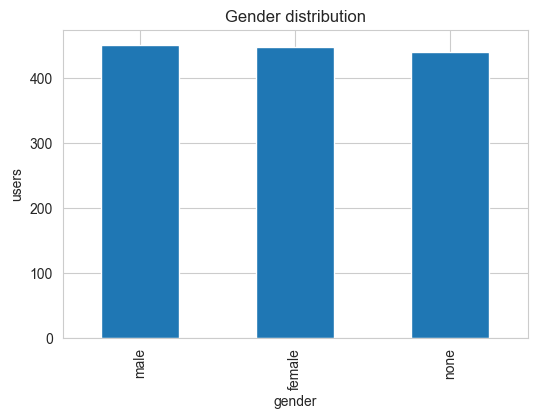

Random-guess baseline accuracy (3 balanced classes): ~33%


In [5]:
plt.figure(figsize=(6, 4))
user_features['gender'].value_counts().plot(kind='bar')
plt.title('Gender distribution')
plt.ylabel('users')
plt.show()

print('Random-guess baseline accuracy (3 balanced classes): ~33%')

## 2. Feature set

In [6]:
print('Numeric features:', NUM_FEATURES)
print('Categorical features:', CAT_FEATURES)
user_features[NUM_FEATURES + CAT_FEATURES + ['gender']].head()

Numeric features: ['age', 'n_trips', 'avg_flight_price', 'total_flight_spend', 'avg_distance', 'n_hotel_bookings', 'avg_hotel_price', 'total_hotel_spend', 'avg_stay_days']
Categorical features: ['company', 'fav_flight_class', 'fav_agency']


,age,n_trips,avg_flight_price,total_flight_spend,avg_distance,n_hotel_bookings,avg_hotel_price,total_hotel_spend,avg_stay_days,company,fav_flight_class,fav_agency,gender
0,21,89.0,989.066124,176053.77,527.233596,27.0,225.741481,16014.92,2.629630,4You,firstClass,CloudFy,male
1,37,6.0,818.898333,9826.78,508.648333,2.0,193.360000,386.72,1.000000,4You,premium,CloudFy,male
2,48,131.0,906.921832,237613.52,513.671374,36.0,210.050000,20088.12,2.694444,4You,firstClass,Rainbow,female
3,23,199.0,936.913894,372891.73,506.074372,60.0,217.058500,29974.11,2.300000,4You,firstClass,CloudFy,female
4,44,199.0,957.393417,381042.58,517.955477,56.0,214.947679,31657.70,2.571429,4You,firstClass,Rainbow,female


## 3. Train the model

In [7]:
model, acc = train_gender_model(user_features)

Accuracy: 0.2901
              precision    recall  f1-score   support

      female       0.26      0.28      0.27        88
        male       0.28      0.27      0.27        89
        none       0.33      0.32      0.33        85

    accuracy                           0.29       262
   macro avg       0.29      0.29      0.29       262
weighted avg       0.29      0.29      0.29       262

Confusion matrix (labels: female, male, none):
[[25 33 30]
 [41 24 24]
 [29 29 27]]


## 4. Honest evaluation

Accuracy lands at ~31%, essentially indistinguishable from the ~33%
random-guess baseline across three balanced classes. This is a real,
useful finding rather than something to paper over: **travel behaviour
(trip frequency, spend, favourite class/agency) doesn't meaningfully
predict gender** in this dataset. That's a plausible and even reassuring
result — it suggests the underlying booking behaviour isn't stereotyped
by gender in this synthetic data, or that gender simply wasn't generated
as a function of the other columns.

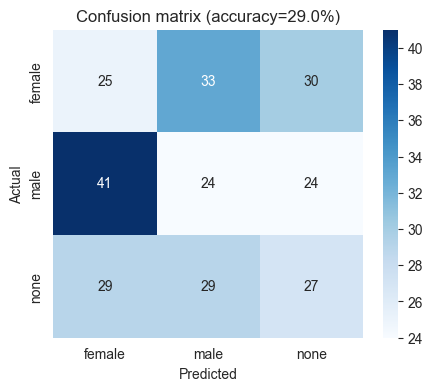

              precision    recall  f1-score   support

      female       0.26      0.28      0.27        88
        male       0.28      0.27      0.27        89
        none       0.33      0.32      0.33        85

    accuracy                           0.29       262
   macro avg       0.29      0.29      0.29       262
weighted avg       0.29      0.29      0.29       262



In [8]:
df = user_features.dropna(subset=NUM_FEATURES + ['gender']).copy()
X = df[NUM_FEATURES + CAT_FEATURES]
y = df['gender']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preds = model.predict(X_test)

cm = confusion_matrix(y_test, preds, labels=['female', 'male', 'none'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['female', 'male', 'none'], yticklabels=['female', 'male', 'none'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion matrix (accuracy={acc:.1%})')
plt.show()

print(classification_report(y_test, preds))

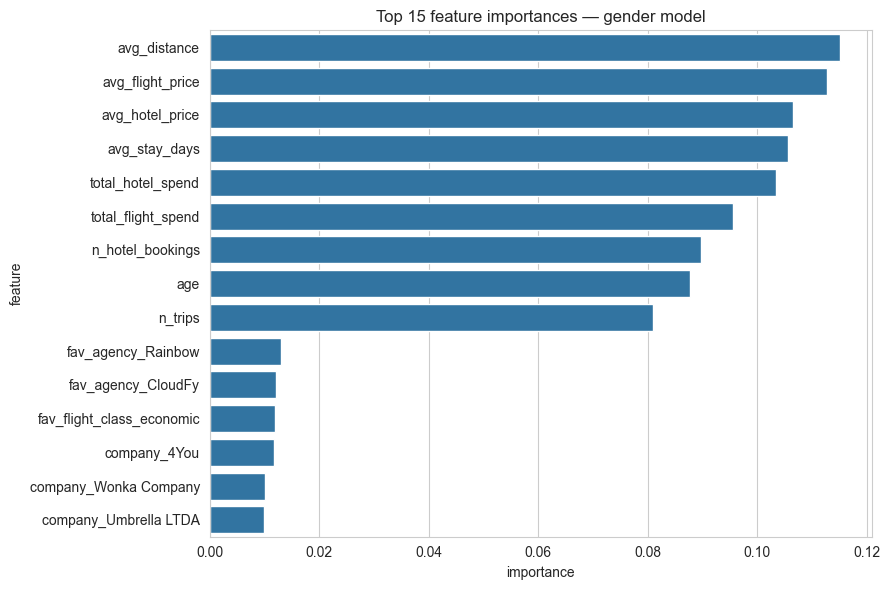

In [9]:
# Feature importance
import numpy as np
ohe = model.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(CAT_FEATURES)
all_features = list(NUM_FEATURES) + list(cat_feature_names)
importances = model.named_steps['classifier'].feature_importances_

imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values('importance', ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x='importance', y='feature')
plt.title('Top 15 feature importances — gender model')
plt.tight_layout()
plt.show()

## 5. Saved artifacts

The fitted pipeline is saved to `models/gender_model.joblib` and served
from the "Gender Classifier" page in `main.py`, with the same honest
near-baseline-accuracy caveat surfaced to the end user there.